# Data Visualization and First Machine Learning Model  
## Matplotlib, Seaborn, Scikit-Learn, and Linear Regression

This notebook is designed for students learning machine learning for the first time.

Focuses on **data visualization**:

- Matplotlib basics
- Object-Oriented plotting
- Subplots
- Seaborn distribution plots
- Correlation heatmaps
- Pairplots

Introducing **supervised machine learning**:

- Feature matrix `X`
- Target vector `y`
- Train-test split
- Linear regression
- Model coefficients
- Prediction
- Evaluation using MSE and R²
- Actual vs predicted visualization

The goal is to show students how visualization and machine learning connect.

---

# Instructor Setup Note

In Google Colab, these libraries are usually already installed:

```python
matplotlib
seaborn
scikit-learn
numpy
pandas
```

If students get an import error, run:

```python
!pip install matplotlib seaborn scikit-learn
```

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

print("Day 7-8 Visualization and Machine Learning Environment Initialized.")

Day 7-8 Visualization and Machine Learning Environment Initialized.


---

# Matplotlib Basics and Subplots

## Explanation

Matplotlib is one of the most important plotting libraries in Python.

There are two common ways to use Matplotlib:

1. Simple `plt` style  
2. Object-Oriented API using `Figure` and `Axes`

For professional work, the Object-Oriented API is preferred because it gives more control.

In this example, we simulate model training over 10 epochs and plot:

- Training loss
- Accuracy

In [ ]:
epochs = np.arange(1, 11)

loss = [0.95, 0.72, 0.55, 0.41, 0.33, 0.28, 0.24, 0.21, 0.19, 0.18]
accuracy = [0.50, 0.65, 0.75, 0.82, 0.88, 0.91, 0.93, 0.95, 0.96, 0.97]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, loss, color="red", marker="o", linestyle="--")
ax1.set_title("Model Training Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.grid(True)

ax2.plot(epochs, accuracy, color="blue", marker="s")
ax2.set_title("Model Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.grid(True)

plt.tight_layout()
plt.show()

## How to Explain This to Students

The loss curve should usually go downward. That means the model is making smaller errors over time.

The accuracy curve should usually go upward. That means the model is making more correct predictions over time.

If training loss decreases but test accuracy does not improve, the model may be overfitting.

---

# Extra Cell 1: Single Plot Anatomy

A good plot should usually have:

- Title
- X-axis label
- Y-axis label
- Clear markers or lines
- Grid when helpful

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(epochs, loss, marker="o")
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

---

# Extra Cell 2: Bar Chart for Model Comparison

A bar chart is useful when comparing categories.

Here we compare validation accuracy of three models.

In [ ]:
model_names = ["Linear Regression", "Random Forest", "Neural Network"]
validation_scores = [0.78, 0.86, 0.91]

plt.figure(figsize=(7, 4))
plt.bar(model_names, validation_scores)
plt.title("Validation Score by Model")
plt.xlabel("Model")
plt.ylabel("Validation Score")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.show()

---

# Seaborn: Statistical Visualization

Seaborn is built on top of Matplotlib and works very well with Pandas DataFrames.

Here we create a simulated dataset of multimodal student scores.

Each row represents one student.

Features:

- `Vision_Score`
- `Text_Score`
- `Study_Hours`

Target:

- `Final_Score`

In [3]:
np.random.seed(42)

df = pd.DataFrame({
    "Vision_Score": np.random.normal(85, 8, 200),
    "Text_Score": np.random.normal(80, 10, 200),
    "Study_Hours": np.random.uniform(10, 50, 200)
})

df["Final_Score"] = (
    df["Vision_Score"] * 0.5
    + df["Text_Score"] * 0.3
    + df["Study_Hours"] * 0.4
    + np.random.normal(0, 3, 200)
)

display(df.head())

,Vision_Score,Text_Score,Study_Hours,Final_Score
0,88.973713,83.577874,26.592780,81.210139
1,83.893886,85.607845,20.936283,74.768179
2,90.181508,90.830512,12.255020,75.779097
3,97.184239,90.538021,44.588895,92.291409
4,83.126773,66.223306,42.516040,79.620151


---

# Seaborn Distribution Plot

A distribution plot shows how one variable is spread.

For `Final_Score`, this helps us answer:

- Are most students clustered around one score range?
- Are there very low or very high outliers?
- Is the distribution close to a bell curve?

The KDE line gives a smooth approximation of the distribution shape.

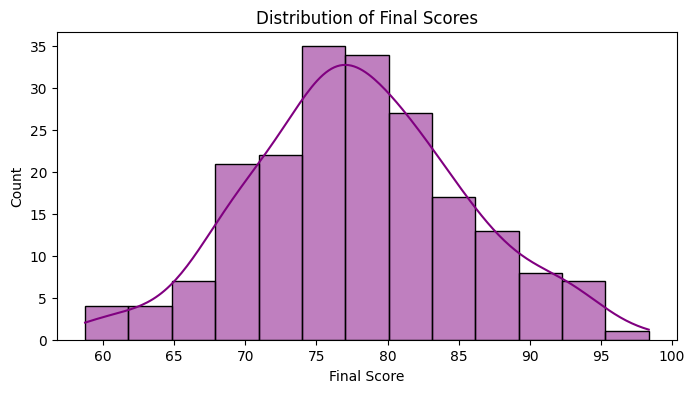

In [4]:
plt.figure(figsize=(8, 4))
sns.histplot(df["Final_Score"], kde=True, color="purple")
plt.title("Distribution of Final Scores")
plt.xlabel("Final Score")
plt.ylabel("Count")
plt.show()

---

# Extra Cell 3: Boxplot for Outlier Detection

A boxplot helps detect spread and possible outliers.

Outliers can affect machine learning models, especially linear regression.

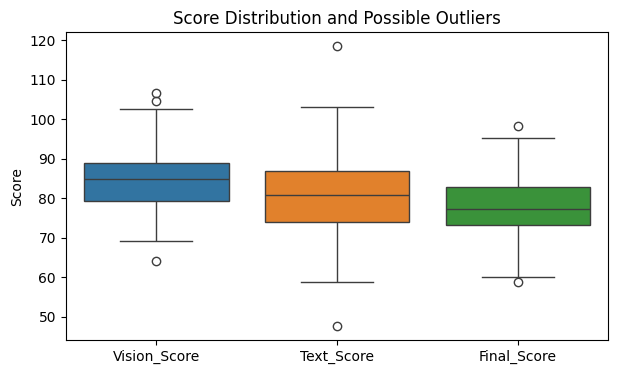

In [5]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df[["Vision_Score", "Text_Score", "Final_Score"]])
plt.title("Score Distribution and Possible Outliers")
plt.ylabel("Score")
plt.show()

---

# Seaborn: Correlation Heatmap

Before feeding features into a linear regression model, we should ask:

Which features actually relate to the target?

Correlation helps measure linear relationship.

| Value | Meaning |
|---|---|
| Close to +1 | Strong positive relationship |
| Close to 0 | Weak or no linear relationship |
| Close to -1 | Strong negative relationship |

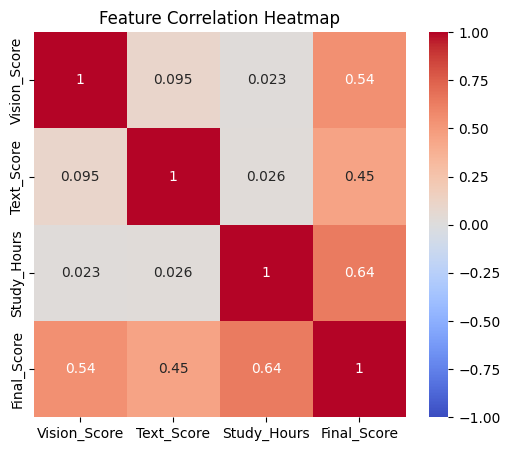

In [6]:
corr_matrix = df.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Feature Correlation Heatmap")
plt.show()

---

# Seaborn Pairplot

A pairplot compares every numerical column against every other numerical column.

It helps us visually inspect:

- Linear relationships
- Nonlinear patterns
- Clusters
- Outliers
- Distribution shapes

In [ ]:
sns.pairplot(df, corner=True, diag_kind="kde")
plt.suptitle("Dataset Pairplot", y=1.02)
plt.show()

---

# Extra Cell 4: Scatter Plot with Regression Line

A scatter plot shows the relationship between two variables.

A regression line helps students see the trend.

In [ ]:
plt.figure(figsize=(7, 5))
sns.regplot(data=df, x="Vision_Score", y="Final_Score")
plt.title("Vision Score vs Final Score")
plt.xlabel("Vision Score")
plt.ylabel("Final Score")
plt.show()

---

# Day 8: Introduction to Machine Learning

Now we move into supervised learning.

In supervised learning, the model learns from examples where the correct answer is already known.

For this dataset:

| ML Term | In Our Example |
|---|---|
| Features / Inputs | Vision Score, Text Score, Study Hours |
| Target / Output | Final Score |
| Model task | Predict final score |

---

# Feature Matrix `X` and Target Vector `y`

In scikit-learn, we usually separate data into:

```python
X = inputs/features
y = output/target
```

`X` is usually a table or matrix.

`y` is usually one column.

In [7]:
X = df[["Vision_Score", "Text_Score", "Study_Hours"]]
y = df["Final_Score"]

print("Feature matrix X:")
display(X.head())

print("\nTarget vector y:")
display(y.head())

Feature matrix X:


,Vision_Score,Text_Score,Study_Hours
0,88.973713,83.577874,26.592780
1,83.893886,85.607845,20.936283
2,90.181508,90.830512,12.255020
3,97.184239,90.538021,44.588895
4,83.126773,66.223306,42.516040



Target vector y:


0    81.210139
1    74.768179
2    75.779097
3    92.291409
4    79.620151
Name: Final_Score, dtype: float64

---

# Train-Test Split

We split the dataset into two parts:

| Split | Purpose |
|---|---|
| Training data | Used to teach the model |
| Testing data | Used to evaluate the model on unseen examples |

This helps prevent data leakage.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Total dataset size: {len(df)}")
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")

Total dataset size: 200
Training features shape: (160, 3)
Testing features shape: (40, 3)
Training target shape: (160,)
Testing target shape: (40,)


---

# The Scikit-Learn API: Linear Regression

Most scikit-learn models follow the same pattern:

```python
model = ModelName()
model.fit(X_train, y_train)
predictions = model.predict(X_test)
```

Linear regression learns an equation like:

```text
Final_Score = bias + w1*Vision_Score + w2*Text_Score + w3*Study_Hours
```

In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)

print("--- Learned Model Parameters ---")
print(f"Bias (Intercept): {model.intercept_:.2f}")

# print("Weights (Coefficients):")
# for feature, weight in zip(X.columns, model.coef_):
#     print(f"- {feature}: {weight:.4f}")

--- Learned Model Parameters ---
Bias (Intercept): -0.61
Weights (Coefficients):
- Vision_Score: 0.4772
- Text_Score: 0.3275
- Study_Hours: 0.4033


## How to Interpret the Coefficients

Each coefficient tells us how much the prediction changes when that feature increases by 1 unit, assuming the other features stay the same.

Because we created the synthetic dataset using known weights, the learned weights should be close to the original formula.

---

# Model Evaluation

After training, we test the model on unseen data.

We use two common regression metrics:

## Mean Squared Error

MSE measures the average squared prediction error. Lower is better.

## R-squared Score

R² tells us how much variation in the target is explained by the model.

| R² Value | Meaning |
|---|---|
| Close to 1 | Very good |
| Around 0 | Not useful |
| Negative | Worse than predicting the mean |

In [13]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- Model Evaluation ---")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared Score: {r2:.4f} (Closer to 1.0 is better)")

--- Model Evaluation ---
Mean Squared Error: 9.54
R-squared Score: 0.8343 (Closer to 1.0 is better)


---

# Actual vs Predicted Plot

This plot compares actual final scores with predicted final scores.

The dashed diagonal line is the line of perfect prediction.

If points are close to this line, the model is performing well.

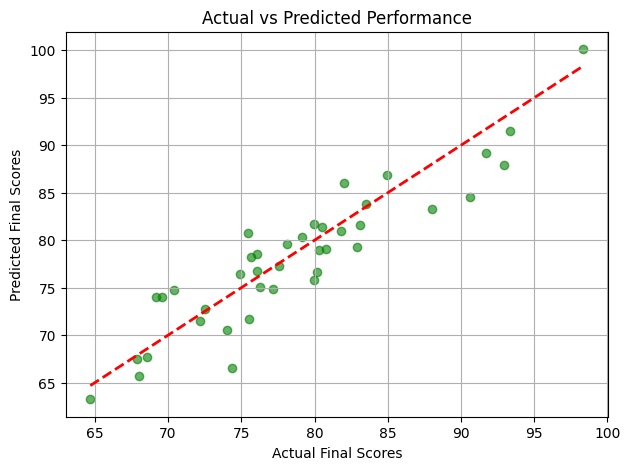

In [14]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, color="green", alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--",
    linewidth=2
)
plt.xlabel("Actual Final Scores")
plt.ylabel("Predicted Final Scores")
plt.title("Actual vs Predicted Performance")
plt.grid(True)
plt.show()

---

# Extra Cell 5: Residual Analysis

A residual is the error for one prediction.

```text
Residual = Actual - Predicted
```

For a good linear regression model, residuals should be randomly scattered around zero.

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(7, 5))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Final Score")
plt.ylabel("Residual Error")
plt.title("Residual Plot")
plt.grid(True)
plt.show()

print(f"Average residual: {np.mean(residuals):.4f}")

---

# Extra Cell 6: Prediction for a New Student

After training a model, we can use it to predict a new example.

Suppose a student has:

- Vision score: 90
- Text score: 84
- Study hours: 35

In [ ]:
new_student = pd.DataFrame({
    "Vision_Score": [90],
    "Text_Score": [84],
    "Study_Hours": [35]
})

new_prediction = model.predict(new_student)

display(new_student)
print(f"Predicted Final Score: {new_prediction[0]:.2f}")

---

# Extra Cell 7: Simple Train vs Test Score

If training score is very high but testing score is much lower, the model may be overfitting.

In [ ]:
train_r2 = model.score(X_train, y_train)
test_r2 = model.score(X_test, y_test)

print(f"Training R² Score: {train_r2:.4f}")
print(f"Testing R² Score: {test_r2:.4f}")

---

# Hands-On Coding Test

The following problems are for students to solve independently.

No solutions are provided in this test section.

# Test 1: Easy  
## Matplotlib Line Plot

You are given training loss values for 8 epochs:

```python
epochs = np.arange(1, 9)
loss = [1.2, 0.95, 0.78, 0.61, 0.50, 0.42, 0.36, 0.31]
```

Write Python code to:

1. Plot loss against epochs
2. Add markers to the line
3. Add a title
4. Add x-axis and y-axis labels
5. Turn on the grid

In [ ]:
# Test 1 Student Code

import numpy as np
import matplotlib.pyplot as plt

epochs = np.arange(1, 9)
loss = [1.2, 0.95, 0.78, 0.61, 0.50, 0.42, 0.36, 0.31]

# Write your solution here

---

# Test 2: Medium  
## Seaborn EDA

Create the following DataFrame:

```python
df_test = pd.DataFrame({
    "Hours_Studied": [2, 3, 5, 6, 8, 9, 10],
    "Practice_Tests": [1, 1, 2, 3, 3, 4, 5],
    "Final_Score": [55, 60, 70, 75, 85, 88, 95]
})
```

Write Python code to:

1. Display the DataFrame
2. Create a histogram of `Final_Score` using Seaborn
3. Calculate the correlation matrix
4. Create a heatmap with correlation values shown on the plot

In [ ]:
# Test 2 Student Code

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_test = pd.DataFrame({
    "Hours_Studied": [2, 3, 5, 6, 8, 9, 10],
    "Practice_Tests": [1, 1, 2, 3, 3, 4, 5],
    "Final_Score": [55, 60, 70, 75, 85, 88, 95]
})

# Write your solution here

---

# Test 3: Hard  
## Train and Evaluate a Linear Regression Model

Using the `df_test` dataset from Test 2:

1. Set `X` as `Hours_Studied` and `Practice_Tests`
2. Set `y` as `Final_Score`
3. Split the data into training and testing sets using `test_size=0.3` and `random_state=42`
4. Train a `LinearRegression` model
5. Print the learned intercept and coefficients
6. Predict on the test set
7. Print MSE and R² score
8. Create an Actual vs Predicted scatter plot

In [ ]:
# Test 3 Student Code

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Use df_test from Test 2 or recreate it here

# Write your solution here

---

# End of Day 7–8 Notebook

By the end of this notebook, students should understand:

- How to use Matplotlib for controlled plotting
- How subplots work
- How Seaborn supports statistical visualization
- How histograms, boxplots, heatmaps, pairplots, and regression plots help EDA
- Why we split data into training and testing sets
- How the scikit-learn API works
- How to train a Linear Regression model
- How to interpret coefficients
- How to evaluate regression using MSE and R²
- How to visually inspect predictions and residual errors

This notebook connects data visualization directly to the first supervised machine learning workflow.